In [1]:
# The Important Change in this Routine is the Use of Trimmed data - Making sure that after 
# Overscan and trim, all data files: bias, flat, dark and light files are of the exact same size
# because if not we won't be able to perform calculations on them.

In [2]:
from astropy.io import fits
from matplotlib import pyplot as plt
import numpy as np
from convenience_functions import show_image
from ccdproc import ImageFileCollection
import ccdproc as ccdp
from pathlib import Path

In [3]:
# Looking at the header for one set of data:
#hdu_list = fits.open('/Users/applestore/exo-observe/Data/GJ-1214b/raw_data/d-UW32R001.fits')
#hdu = hdu_list[0]
#hdu.header

In [5]:
# Looking at the headers of all files in one directory collectively
data_directory = '/Users/applestore/exo-observe/Data/GJ-1214b/trim'

image_path = Path(data_directory)

image_path.mkdir(parents=True, exist_ok=True)

im = ccdp.ImageFileCollection(data_directory)
#science= im.summary
#science['obstype', 'exptime','darktime','date-obs', 'crval1', 'crval2']

# Method 2 just to get a list of file names.
#dark_files = im.summary[im.summary['obstype'] == 'DARK']['file']
#print (dark_files)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ccdproc/image_collection.py:548: UserWarning: Header from file "/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-DARKR001_T.fits" contains multiple entries for "dtm1_1", the pair "dtm1_1=1.0" will be ignored.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ccdproc/image_collection.py:548: UserWarning: Header from file "/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-DARKR001_T.fits" contains multiple entries for "dtm2_2", the pair "dtm2_2=1.0" will be ignored.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ccdproc/image_collection.py:548: UserWarning: Header from file "/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-DARKR001_T.fits" contains multiple entries for "dtv1", the pair "dtv1=0.0" will be ignored.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/

In [6]:
# I don't have access to the bias files of this data set so I am trying to build one on my
# own. But the first necessary step in doing that is to find the exact size of the fits files so that
# after I construct the biases there ain't no problem reducing it from the object frames. So:

# Finding the Size of a single fit's array

data=fits.getdata("/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R270_T.fits")

print(data.shape)

(2048, 503)


(2048, 503)


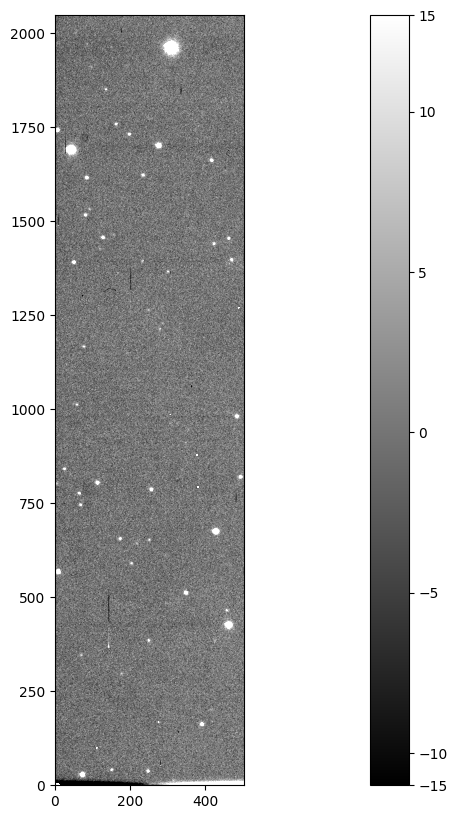

In [7]:
# I run this step to see the min and max pixel values of my image in the gray-color bar below
# Then I enter those two values in the next code block as vmin and vmax when plotting so that
# I get as much data visible on color plots as I can. Other wise the image would be all yellow or all blue (loosing)
# many data points.
sflat=fits.getdata("/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R038_T.fits")
print(sflat.shape)
show_image(sflat, cmap='gray')

Text(0.5, 1.0, 'north up, east left')

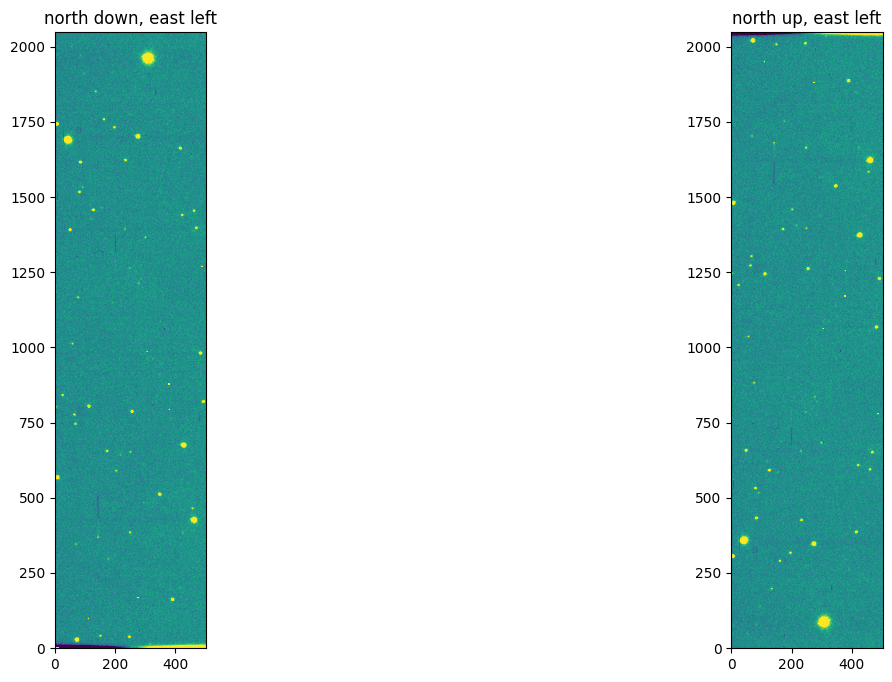

In [8]:
# This bit show the fits image in different orientations

#import matplotlib.pyplot as plt

f,axs=plt.subplots(1,2,figsize=(16,8))
axs[0].imshow(sflat,vmin=-15,vmax=15,origin='lower')
axs[0].set_title("north down, east left")
axs[1].imshow(np.flipud(sflat),vmin=-15,vmax=15,origin='lower')
axs[1].set_title("north up, east left")

<Figure size 640x480 with 0 Axes>

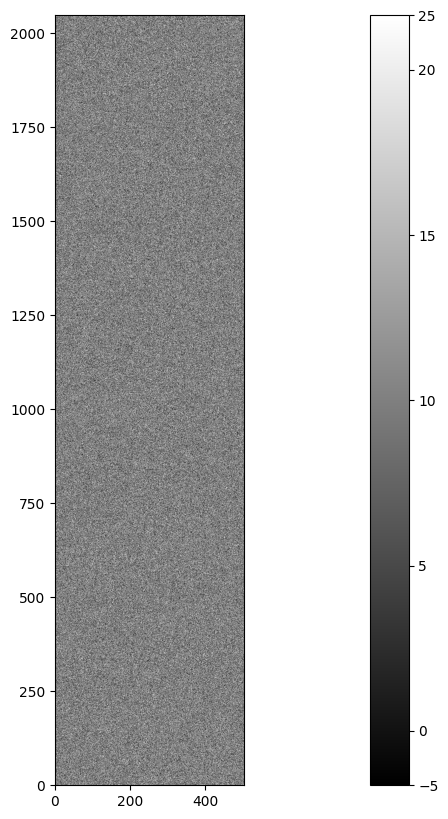

In [9]:
# Creating Fake Bias frames: - Pay attention to size definition
import os
synthetic_image = np.zeros([2048, 503])
def read_noise(image, amount, gain=1):
    """
    Generate simulated read noise.
    
    Parameters
    ----------
    
    image: numpy array
        Image whose shape the noise array should match.
    amount : float
        Amount of read noise, in electrons.
    gain : float, optional
        Gain of the camera, in units of electrons/ADU.
    """
    shape = image.shape
    
    noise = noise_rng.normal(scale=amount/gain, size=shape)
    
    return noise

def bias(image, value, realistic=False):
    """
    Generate simulated bias image.
    
    Parameters
    ----------
    
    image: numpy array
        Image whose shape the bias array should match.
    value: float
        Bias level to add.
    realistic : bool, optional
        If ``True``, add some columns with somewhat higher bias value (a not uncommon thing)
    """
    # This is the whole thing: the bias is really suppose to be a constant offset!
    bias_im = np.zeros_like(image) + value
    
    # If we want a more realistic bias we need to do a little more work. 
    if realistic:
        shape = image.shape
        number_of_colums = 5
        
        # We want a random-looking variation in the bias, but unlike the readnoise the bias should 
        # *not* change from image to image, so we make sure to always generate the same "random" numbers.
        rng = np.random.RandomState(seed=8392)  # 20180520
        columns = rng.randint(0, shape[1], size=number_of_colums)
        # This adds a little random-looking noise into the data.
        col_pattern = rng.randint(0, int(0.1 * value), size=shape[0])
        
        # Make the chosen columns a little brighter than the rest...
        for c in columns:
            bias_im[:, c] = value + col_pattern
            
    return bias_im
        

# Set up the random number generator, allowing a seed to be set from the environment
seed = os.getenv('GUIDE_RANDOM_SEED', None)

if seed is not None:
    seed = int(seed)
    
# This is the generator to use for any image component which changes in each image, e.g. read noise
# or Poisson error
noise_rng = np.random.default_rng(seed)

plt.figure()
noise_im = synthetic_image + read_noise(synthetic_image, 5)
bias_only = bias(synthetic_image, 10, realistic=True)
bias_noise_im = noise_im + bias_only
show_image(bias_noise_im, cmap='gray', figsize=(10, 10))
#plt.title('Realistic bias frame (includes read noise)', fontsize='20')

In [10]:
# If I have real bias files I will go through with this step. But as I have built one here
# myself I see no reason making more and then a master bias out of them. So insted I will pass this
# one single File that I have for now as the superbias file in the following code and this should definitely change later.
superbias = bias_noise_im
print(superbias.shape)
# combining bias frame to get a Master-bias:

 ## let's fist check the bias image
#import glob
#bfiles=glob.glob("/Users/applestore/exo-observe/Data/HAT-32b/raw_data/d*BIASR*.fit")
#bfiles.sort()
#allbias=[]
#print("combining bias ...")
#for i,ifile in enumerate(bfiles):
# print("reading bias:", i+1,len(bfiles),ifile)
# data=fits.getdata(ifile)
# allbias.append(data)
#allbias=np.stack(allbias)
#print(allbias.shape)
#superbias=np.median(allbias,axis=0)
fits.writeto('/Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/bias.fit',superbias.astype('float32'),overwrite=True)

(2048, 503)


Text(0.5, 1.0, 'Master bias drived from bias frames')

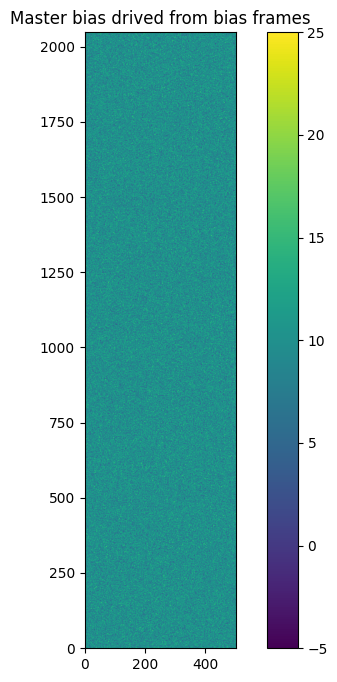

In [11]:
## display the Master bias
plt.figure(figsize=(8,8))
plt.imshow(superbias,vmin=-5,vmax=25,origin='lower')
plt.colorbar()
plt.title("Master bias drived from bias frames")

In [12]:
#dark_files = files.summary[files.summary['obstype'] == 'DARK']['file']
#print (dark_files)

In [13]:
single_flat=fits.getdata("/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR006_T.fits")
print(single_flat.shape)


(2048, 503)


In [16]:
# combining dome flats (with bias correction)
import glob
ffiles=glob.glob("/Users/applestore/exo-observe/Data/GJ-1214b/trim/d*FLATR*.fits")
ffiles.sort()
allflat=[]
print("combining dome flats...")
for i,ifile in enumerate(ffiles):
 print("reading flat:", i+1,len(ffiles),ifile)

 # flat-fielding: subtract bias and then normalize the flat images
# data=fits.getdata(ifile)
 data=fits.getdata(ifile)-superbias
# mflat=np.median(data[1500-256:1500+256,1500-256:1500+256])

 mflat = np.median(data[int(data.shape[0]/2)-128:int(data.shape[0]/2)+128, int(data.shape[1]/2)-128:int(data.shape[1]/2)+128])

 data/=mflat
 print("median flat:",mflat)
 allflat.append(data)
allflat=np.stack(allflat)
print(allflat.shape)
domeflat=np.median(allflat,axis=0)
print(domeflat.shape)

fits.writeto('/Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/T-domeflat.fits',domeflat.astype('float32'),overwrite=True)

combining dome flats...
reading flat: 1 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR001_T.fits
median flat: -85.91660982610156
reading flat: 2 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR002_T.fits
median flat: -10.002707822508945
reading flat: 3 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR003_T.fits
median flat: -82.56032371039285
reading flat: 4 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR004_T.fits
median flat: -99.10802581865394
reading flat: 5 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR005_T.fits
median flat: -103.4624932486011
reading flat: 6 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR006_T.fits
median flat: -15.050776193798196
reading flat: 7 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR007_T.fits
median flat: -73.74204221765388
reading flat: 8 16 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR008_T.fits
median flat: -68.5174049187674
reading flat: 9 16 /Users/apple

In [17]:
# To find vmin and vmax for below:
#show_image(domeflat, cmap='gray', figsize=(10, 10))


Text(0.5, 1.0, 'Master Flat drived from flat frames')

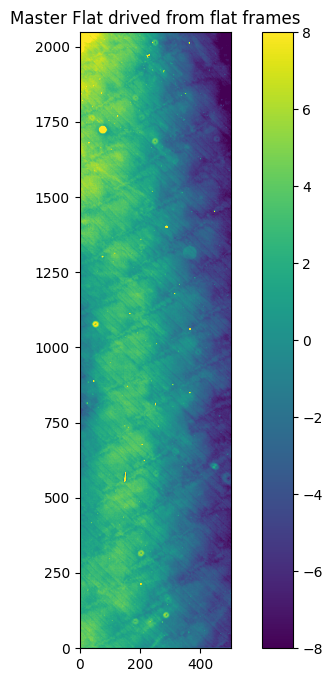

In [18]:
## display the Master flat
plt.figure(figsize=(8,8))
plt.imshow(domeflat,vmin=-8,vmax=8,origin='lower')
plt.colorbar()
plt.title("Master Flat drived from flat frames")

In [19]:
# Since I don't have real bias for this: I am using the fake bias file I built twice.
# We can calculate gain and readout noise from pairs of bias and flats
# The algorithm come from the IRAF FINDGAIN program, please refer to its help information

## calculate gain and read noise
from astropy.stats import sigma_clipped_stats
biasfile1='/Users/applestore/exo-observe/Data/HAT-32b/raw_data/d4466637BIASR213.fit'
biasfile2='/Users/applestore/exo-observe/Data/HAT-32b/raw_data/d4466637BIASR214.fit'
#flatfile1='/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR007_T.fits'
#flatfile2='/Users/applestore/exo-observe/Data/GJ-1214b/trim/d-FLATR016_T.fits'
flatfile1='/Users/applestore/exo-observe/Data/HAT-32b/raw_data/d4466637FLATR201.fit'
flatfile2='/Users/applestore/exo-observe/Data/HAT-32b/raw_data/d4466637FLATR202.fit'


bias1=fits.getdata(biasfile1)[1500-256:1500+256,1500-256:1500+256]
bias2=fits.getdata(biasfile2)[1500-256:1500+256,1500-256:1500+256]

# These lines work for the dimensions of the GJ-1214b data files. But since I don't have real bias, the resulting gain
# and readout noise because meaninglessly small. So although I have learnt the process but just for now I switch back
# to using HAT-32b data
flat1 = fits.getdata(flatfile1)[1500-256:1500+256,1500-256:1500+256]
flat2=fits.getdata(flatfile2)[1500-256:1500+256,1500-256:1500+256]
#flat1 = fits.getdata(flatfile1)
#flat2 = fits.getdata(flatfile2)
mean_flat1=np.median(flat1)
print(mean_flat1)
mean_flat2=np.median(flat2)
mean_bias1=np.median(bias1)
mean_bias2=np.median(bias2)
_,_,std_biasdiff=sigma_clipped_stats(bias1-bias2,sigma=4.0,maxiters=2)
_,_,std_flatdiff=sigma_clipped_stats(flat1-flat2,sigma=4.0,maxiters=2)
print(mean_bias1,mean_bias2,mean_flat1,mean_flat2,std_biasdiff,std_flatdiff)
gain=((mean_flat1+mean_flat2)-(mean_bias1+mean_bias2))/((std_flatdiff**2-std_biasdiff**2))
rdnoise=gain*std_biasdiff/np.sqrt(2)
print("gain: ",gain, "readout noise:",rdnoise)

8986.0
0.0 0.0 8986.0 9160.0 2.905397 72.79242
gain:  3.430054470497312 readout noise: 7.046792664146595


In [20]:
from astropy.coordinates import SkyCoord
import astropy.units as u
import glob,os
c=SkyCoord("17:25:33.46","+4:37:25.57",frame='icrs',unit=(u.hourangle,u.degree))
ra=c.ra.degree; dec=c.dec.degree
print("ra:", ra, "dec:",c.dec.degree)
epoch=2000.0
pixscale=0.137 # in arcsec
# add keywords to FITS header of science frames
outdir="/Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/"
sfiles=glob.glob("/Users/applestore/exo-observe/Data/GJ-1214b/trim/d*UW32R*.fits") # science frames
sfiles.sort() # in alphabetic order
for i,ifile in enumerate(sfiles):
 print("reducing (debias, flat-fielding, and flipping) :", i+1,len(sfiles),ifile)
 indir,infile=os.path.split(ifile)
 rootname,_=os.path.splitext(infile)
 # we change the first character from "d" to "p" for new files and ensure not to cover the raw data
 outfile=os.path.join(outdir,"p"+rootname[1:]+'.fits')
 head=fits.getheader(ifile,output_verifystr="silentfix")
 # get the origin of the subregion
 col_origin=head['CRVAL1']
 row_origin=head['CRVAL2']
 
 # I have chosen not to use subflat and sub bias for now but rather use all of it:
    
 #subflat=domeflat[row_origin:row_origin+512,col_origin:col_origin+512]
 #subbias=superbias[row_origin:row_origin+512,col_origin:col_origin+512]
 #subflat = domeflat[100:100+512, 200:200+512]
 #subbias = superbias[100:100+512, 200:200+512]
 #if i==0:
 ## to show an example of the subsection of bias and flat
 #    fits.writeto('/Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/subflat.fits',subflat.astype('float32'),overwrite=True)
 #    fits.writeto('/Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/subbias.fits',subbias.astype('float32'),overwrite=True)
 #break
 data=fits.getdata(ifile)

 # de-bias and flat-fielding
# data = data[100:100+512, 200:200+507]
# data = data[:, :363]
# data=(data-subbias)/subflat

 # I have chosen not to use subflat and sub bias for now but rather use all of it:

# data = data[:, :503]
 data=(data-superbias)/domeflat
# set the initial reference point in the WCS parameters if doing astrometry
 head['epoch']=2000.0


 # set the initial reference point in the WCS parameters if doing astrometry
 head['epoch']=2000.0
 head['CRVAL1']=ra
 head['CRVAL2']=dec
# head['CRPIX1']=head['NAXIS1']/2.0
# head['CRPIX2']=head['NAXIS2']/2.0
 head['CDELT1']=-pixscale/3600.0 # minus for left east
 head['CDELT2']=pixscale/3600.0
 head['CTYPE1']='RA---TAN' # projection type
 head['CTYPE2']='DEC--TAN'
 head['GAIN']=(gain,'GAIN in e-/ADU')
 head['RDNOISE']=(rdnoise,'readout noise in electron')
 print("writing to "+outfile)
 # flip up down to make the image with north up and east left
 fits.writeto(outfile,np.flipud(data),header=head,overwrite=True,output_verify="silentfix")


ra: 261.38941666666665 dec: 4.623769444444445
reducing (debias, flat-fielding, and flipping) : 1 300 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R001_T.fits
writing to /Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/p-UW32R001_T.fits
reducing (debias, flat-fielding, and flipping) : 2 300 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R002_T.fits
writing to /Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/p-UW32R002_T.fits
reducing (debias, flat-fielding, and flipping) : 3 300 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R003_T.fits
writing to /Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/p-UW32R003_T.fits
reducing (debias, flat-fielding, and flipping) : 4 300 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R004_T.fits
writing to /Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/p-UW32R004_T.fits
reducing (debias, flat-fielding, and flipping) : 5 300 /Users/applestore/exo-observe/Data/GJ-1214b/trim/d-UW32R005_T.fits


In [21]:
# Next Performing Photometry:

# This step converts CCD counts to the physical flux. We don't make flux calibration here, since we aim to get 
# light curve from relative photometry (differential photometry)

# get sky and sky mask

In [26]:

#data=fits.getdata('/Users/applestore/exo-observe/Data/GJ-1214b/reduced_data/p-UW32R023.fits')
from photutils.segmentation import SegmentationImage
from photutils.utils import circular_footprint
from astropy.stats import SigmaClip
from photutils.segmentation import detect_threshold, detect_sources
import photutils as pht
## or first mask sources then estimate the sky background
sigma_clip = SigmaClip(sigma=3.0, maxiters=10)
threshold = detect_threshold(data, nsigma=2.0, sigma_clip=sigma_clip)
segment_img = detect_sources(data, threshold, npixels=10)
footprint = circular_footprint(radius=3)
mask = segment_img.make_source_mask(footprint=footprint)
mean, median, std = sigma_clipped_stats(data, sigma=3.0, mask=mask)
print((mean, median, std))

(-1.4368942092997141, -1.0323117115888705, 5.026434957085323)


In [27]:
## get 2D sky map
from astropy.stats import SigmaClip
sigma_clip = SigmaClip(sigma=3.)
bkg_estimator = pht.SExtractorBackground()
bkg = pht.Background2D(data, (64, 64), mask=mask, filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)

/var/folders/kb/x7gy6w9569jgnxt7cz_dpm1m0000gn/T/ipykernel_3598/128542988.py:4: DeprecationWarning: `photutils.SExtractorBackground` is a deprecated alias for `photutils.background.SExtractorBackground` and will be removed in the future. Instead, please use `from photutils.background import SExtractorBackground` to silence this warning.
  bkg_estimator = pht.SExtractorBackground()
/var/folders/kb/x7gy6w9569jgnxt7cz_dpm1m0000gn/T/ipykernel_3598/128542988.py:5: DeprecationWarning: `photutils.Background2D` is a deprecated alias for `photutils.background.Background2D` and will be removed in the future. Instead, please use `from photutils.background import Background2D` to silence this warning.
  bkg = pht.Background2D(data, (64, 64), mask=mask, filter_size=(3, 3), sigma_clip=sigma_clip, bkg_estimator=bkg_estimator)


In [28]:
print(bkg.background_median,bkg.background_rms_median)

-2.0112528960356917 2.652371312991389


Text(0.5, 1.0, 'background rms')

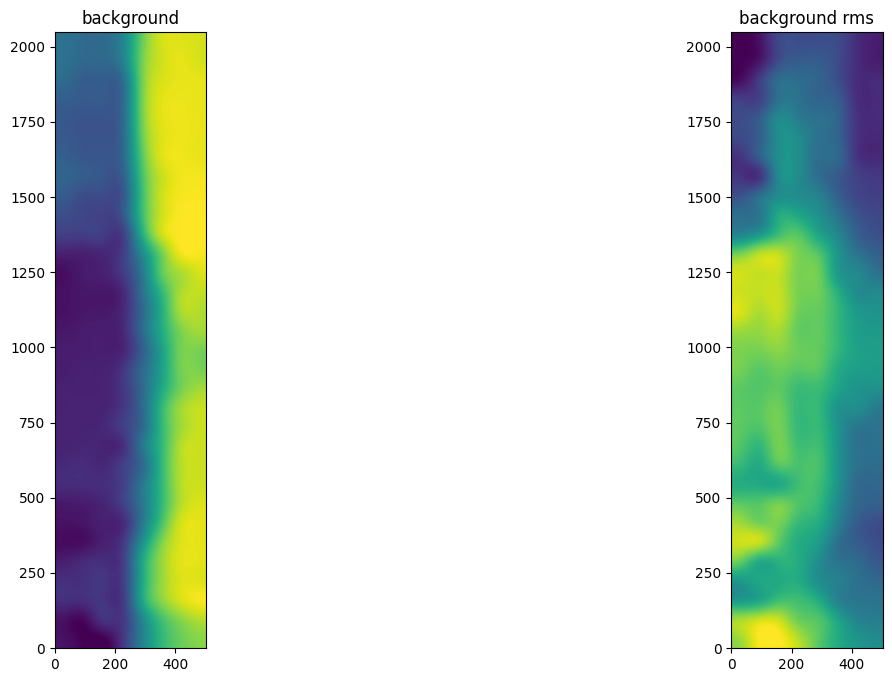

In [29]:
f,axs=plt.subplots(1,2,figsize=(16,8))
axs[0].imshow(bkg.background,origin='lower')
axs[0].set_title("background")
axs[1].imshow(bkg.background_rms,origin='lower')
axs[1].set_title("background rms")

In [32]:
## find objects and calculate basic information
daofind = pht.IRAFStarFinder(fwhm=3.0, threshold=6.*bkg.background_rms_median,exclude_border=True, 
                             sharplo= 0.5, sharphi=2.0, roundlo=0.0, roundhi=0.7)
sources = daofind(data - bkg.background_median)
print(sources)
print(sources.colnames)

/var/folders/kb/x7gy6w9569jgnxt7cz_dpm1m0000gn/T/ipykernel_3598/3161194780.py:2: DeprecationWarning: `photutils.IRAFStarFinder` is a deprecated alias for `photutils.detection.IRAFStarFinder` and will be removed in the future. Instead, please use `from photutils.detection import IRAFStarFinder` to silence this warning.
  daofind = pht.IRAFStarFinder(fwhm=3.0, threshold=6.*bkg.background_rms_median,exclude_border=True,


 id     xcentroid          ycentroid             fwhm        ...         sky                peak               flux                mag        
--- ------------------ ------------------ ------------------ ... ------------------- ------------------ ------------------ -------------------
  1 214.28077349831753 3.3706213019688893 2.2616585020745603 ... -150.15137764981827  294.9245044548794 1506.7227832585363   -7.94508338829182
  2  264.9706882490852 3.6621651343088613 1.8061560462191424 ... -14.616650329215169    86.413258880636 166.87402649341442 -5.5559718628424655
  3  353.2089766090376 11.422024471953087  2.104412685443262 ...   5.379086402681524  16.52377063367921  49.98032593216024  -4.246997709812069
  4 144.67699476800522 14.100787500820573 1.7783500028041976 ...  -4.236463943412142  8.043559586515922 28.195022832129812  -3.625431126532775
  5 227.99192189264247 13.913933582310937 1.5206447754341565 ...   -180.281969471566   5312.67322541693  8279.749420851738   -9.79504298363246

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/photutils/detection/irafstarfinder.py:474: RuntimeWarning: invalid value encountered in divide
  return moments / self.moments[:, 0, 0][:, np.newaxis, np.newaxis]


/var/folders/kb/x7gy6w9569jgnxt7cz_dpm1m0000gn/T/ipykernel_3598/3513916942.py:1: DeprecationWarning: `photutils.CircularAperture` is a deprecated alias for `photutils.aperture.CircularAperture` and will be removed in the future. Instead, please use `from photutils.aperture import CircularAperture` to silence this warning.
  from photutils import CircularAperture


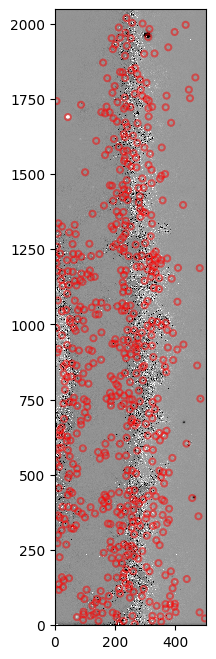

In [39]:
from photutils import CircularAperture
positions = np.transpose((sources['xcentroid'], sources['ycentroid']))
apertures = CircularAperture(positions, r=10.)
plt.figure(figsize=(8,8))
#show_image(data, cmap='gray')
plt.imshow(data, cmap='Greys_r', origin='lower', vmin=-100,vmax=100, interpolation='nearest') 
apertures.plot(color='red', lw=1.5, alpha=0.5)

In [ ]:
# HALT!!! 
# This OBVIOUSLY has the problem of over scan!!! Learn how to solve it once and for all right now!


# Finish Halt! I needed to perform overscann and trim. I did that today.
# Now next step is to perform all the above until the latest step this time with the data in the trim-raw folder 
# (meaning the overscanned and trimmed data)